# LLM Day 1: Introduction to Large Language Models

## Your Journey So Far

```
DL Day 1-2:  Dense Networks → classify points, predict values
DL Day 3:    CNNs → classify images (MNIST, flowers)
DL Day 4:    Transfer Learning → use pre-trained models
     ↓
LLM Day 1:   Large Language Models ← YOU ARE HERE
```

Today we move from **images** to **text**.

## Learning Objectives

1. Understand what LLMs are and see them in action
2. Convert text to numbers (tokenization)
3. Understand attention through code
4. Know Pretraining vs Fine-tuning
5. Generate text with GPT-2

---

## Setup

In [ ]:
# Run this once to install required libraries
# !pip install transformers torch matplotlib --quiet

In [3]:
import torch                      # PyTorch - the deep learning framework
import torch.nn.functional as F   # F contains functions like softmax, relu, etc.
import numpy as np
import matplotlib.pyplot as plt

# Hugging Face transformers - library for working with pre-trained LLMs
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings("ignore")
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
print("Setup complete!")

Setup complete!


---

# Part 1: What is an LLM?

## The One-Sentence Definition

**A Large Language Model (LLM) is a neural network trained to predict the next word.**

That's it. Everything else - conversations, code generation, answering questions - emerges from this simple objective.

```
THE CORE TASK:

    Input:  "The capital of France is"
                         ↓
                   ┌─────────┐
                   │   LLM   │
                   └─────────┘
                         ↓
    Output: probability distribution over ALL possible next words
    
            "Paris"    → 0.82  (82% confident)
            "a"        → 0.05
            "located"  → 0.03
            "the"      → 0.02
            ... 50,000 more words with tiny probabilities ...

The model learned this from reading BILLIONS of documents!
```

---

## Why "Large"?

The "Large" in LLM refers to the **number of parameters** (learnable weights):

```
MODEL SIZE EVOLUTION:

┌─────────────────────────────────────────────────────────────────────┐
│  Model                    Parameters     Year    Training Data     │
├─────────────────────────────────────────────────────────────────────┤
│  Your MNIST CNN (Day 3)   ~100,000       2024    60,000 images     │
│  VGG16 (Day 4)            138 million    2014    1.2M images       │
│  GPT-2                    1.5 billion    2019    40GB text         │
│  GPT-3                    175 billion    2020    570GB text        │
│  GPT-4                    ~1.7 trillion  2023    Trillions tokens  │
│  GPT-5+                   Even larger    2025    Even more data    │
│  Claude (Anthropic)       Undisclosed    2025    Massive datasets  │
└─────────────────────────────────────────────────────────────────────┘

SCALE MATTERS:
    Your CNN:   100,000 parameters
    GPT-2:      1,500,000,000 parameters  (15,000× larger!)
    GPT-4:      ~1,700,000,000,000 parameters  (17 million× larger!)

More parameters = more capacity to learn patterns = better language understanding
```

---

## Why Did LLMs Suddenly Get So Good?

Three key breakthroughs came together:

```
THE PERFECT STORM (2017-2023):

1. THE TRANSFORMER ARCHITECTURE (2017)
   "Attention Is All You Need" paper
   → Enabled parallel training (much faster!)
   → Better at capturing long-range dependencies
   → We'll learn this today!

2. MASSIVE COMPUTE
   → GPUs/TPUs became powerful enough
   → Companies invested billions in training
   → GPT-3 training: ~$4.6 million in compute

3. MASSIVE DATA
   → The internet has petabytes of text
   → Books, Wikipedia, code, conversations
   → Models learn from human knowledge

Without ANY ONE of these, we wouldn't have ChatGPT!
```

---

## Historical Context: Before Transformers

Before 2017, we used different architectures for text. Understanding why they failed helps appreciate Transformers:

```
EVOLUTION OF SEQUENCE MODELS:

1. RNNs (Recurrent Neural Networks) - 1980s
   ┌─────────────────────────────────────────────────────────────────┐
   │                                                                 │
   │   "The"  →  "cat"  →  "sat"  →  "on"  →  "the"  →  ???        │
   │     ↓        ↓        ↓        ↓        ↓                      │
   │   [RNN] → [RNN] → [RNN] → [RNN] → [RNN] → predict             │
   │     ↓        ↓        ↓        ↓        ↓                      │
   │   state → state → state → state → state                        │
   │                                                                 │
   │   PROBLEM: Process ONE word at a time (slow!)                  │
   │   PROBLEM: By the time we reach word 100, we forgot word 1     │
   │                                                                 │
   └─────────────────────────────────────────────────────────────────┘

2. LSTMs (Long Short-Term Memory) - 1997
   ┌─────────────────────────────────────────────────────────────────┐
   │                                                                 │
   │   Better memory than RNNs (special "gates" control what to     │
   │   remember and forget)                                          │
   │                                                                 │
   │   IMPROVEMENT: Can remember longer sequences (~100 words)       │
   │   STILL SLOW: Still processes one word at a time               │
   │   STILL FORGETS: Very long documents still problematic         │
   │                                                                 │
   └─────────────────────────────────────────────────────────────────┘

3. TRANSFORMERS (2017) - The Game Changer!
   ┌─────────────────────────────────────────────────────────────────┐
   │                                                                 │
   │   📄 "Attention Is All You Need" (Vaswani et al., 2017)        │
   │   https://arxiv.org/abs/1706.03762                              │
   │                                                                 │
   │   "The"   "cat"   "sat"   "on"    "the"    → ALL AT ONCE!     │
   │     ↓       ↓       ↓       ↓       ↓                          │
   │   ┌─────────────────────────────────────┐                      │
   │   │         SELF-ATTENTION              │                      │
   │   │   Every word looks at every word!   │                      │
   │   └─────────────────────────────────────┘                      │
   │                     ↓                                           │
   │                  predict                                        │
   │                                                                 │
   │   ADVANTAGE: Process ALL words in parallel (fast!)             │
   │   ADVANTAGE: Every word can attend to every other word         │
   │   ADVANTAGE: No forgetting - direct connections everywhere     │
   │                                                                 │
   └─────────────────────────────────────────────────────────────────┘
```

**This is why Transformers won:** They're parallel (fast to train) AND don't forget.

The paper's title says it all: you don't need RNNs or LSTMs - **"Attention Is All You Need"**.

Now let's see an LLM in action!

---

## What is a Transformer?

A **Transformer** is a neural network architecture designed specifically for processing sequences (like text). It was introduced in the 2017 paper **"Attention Is All You Need"** (Vaswani et al.).

```
TRANSFORMER = Neural network that uses ATTENTION instead of recurrence

┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│  KEY IDEA: Let every word "look at" every other word directly      │
│                                                                     │
│  OLD WAY (RNNs):           NEW WAY (Transformers):                 │
│  ─────────────────         ────────────────────────                 │
│  word1 → word2 → word3     word1 ←──→ word2 ←──→ word3             │
│    ↓       ↓       ↓         ↑          ↑          ↑               │
│  Sequential processing     └──────────────────────────┘             │
│  (slow, forgets)           All-to-all connections (fast, remembers)│
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

WHY "TRANSFORMER"?
    It TRANSFORMS input sequences into output sequences
    using attention to understand relationships between all positions.

WHAT MAKES IT SPECIAL:
    1. PARALLEL: Process all words at once (not one-by-one like RNNs)
    2. ATTENTION: Every word can attend to every other word
    3. SCALABLE: Can be made very large (billions of parameters)
    4. VERSATILE: Works for translation, generation, classification...
```

> 📄 Paper: https://arxiv.org/abs/1706.03762

We'll learn exactly how attention works in Part 4. For now, let's load a Transformer model and see it in action!

In [4]:
# Load a pre-trained model from Hugging Face
# "gpt2" is a small model (117M parameters) we can run locally
# Other options: "gpt2-medium", "gpt2-large", "distilgpt2", "EleutherAI/gpt-neo-125m"

model_name = "gpt2"

# Tokenizer: converts text to numbers and back
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Model: the neural network that predicts next words
# "CausalLM" = Causal Language Model = predicts next token (left-to-right)
model = AutoModelForCausalLM.from_pretrained(model_name)

print(f"Loaded '{model_name}'")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Loaded 'gpt2'
Parameters: 124,439,808


In [5]:
# Let's see the model predict the next word!

prompt = "The capital of France is"

# Step 1: Convert text to token IDs (numbers)
# return_tensors="pt" → return PyTorch tensor (not Python list)
#   "pt" = PyTorch, could also be "tf" for TensorFlow, "np" for NumPy
inputs = tokenizer(prompt, return_tensors="pt")
print(f"Input IDs shape: {inputs['input_ids'].shape}")  # [batch_size, seq_len]
print(f"Input IDs: {inputs['input_ids']}")

# Step 2: Pass through the model
# torch.no_grad() = disable gradient computation
#   → We're not training (no backprop needed), just doing inference
#   → Saves memory and runs faster
with torch.no_grad():
    outputs = model(**inputs)  # **inputs unpacks dict to keyword args

# Step 3: Get predictions for the LAST position (next word)
# outputs.logits shape: [batch_size, sequence_length, vocab_size] = [1, 5, 50257]
#
# We want: [0, -1, :]
#   0  = first item in batch (we only have 1)
#   -1 = last position in sequence (that's where next-word prediction is!)
#   :  = all vocabulary scores (all 50257 of them)
logits = outputs.logits[0, -1, :]
print(f"\nLogits shape: {logits.shape}  (one score per word in vocabulary)")

Input IDs shape: torch.Size([1, 5])
Input IDs: tensor([[ 464, 3139,  286, 4881,  318]])

Logits shape: torch.Size([50257])  (one score per word in vocabulary)


In [6]:
# Step 4: Convert logits to probabilities
# Logits = raw scores (can be any number: -10, 0, 100, etc.)
# Softmax converts to probabilities (all positive, sum to 1)
# Same softmax you used in Day 3 for image classification!

# F.softmax(logits, dim=-1)
#   dim=-1 means "apply softmax along the LAST dimension"
#   Our logits shape is [50257], so dim=-1 = dim=0 here
#   For 2D [batch, vocab], dim=-1 would normalize each row independently
probs = F.softmax(logits, dim=-1)

# Step 5: Get top 5 predictions
# torch.topk(tensor, k) returns:
#   - values: the k highest values
#   - indices: their positions in the original tensor
top_probs, top_indices = torch.topk(probs, k=5)

print(f"Prompt: '{prompt}'")
print(f"\nTop 5 predictions for next word:")
print("-" * 35)
for prob, idx in zip(top_probs, top_indices):
    word = tokenizer.decode(idx)  # Convert token ID → text
    print(f"  '{word}' → {prob:.1%}")

Prompt: 'The capital of France is'

Top 5 predictions for next word:
-----------------------------------
  ' the' → 8.5%
  ' now' → 4.8%
  ' a' → 4.6%
  ' France' → 3.2%
  ' Paris' → 3.2%


**That's the core of every LLM!** It learned "Paris" often follows "The capital of France is" from reading billions of documents.

In [7]:
# Let's wrap this in a function for easy reuse

def predict_next(prompt, k=5):
    """Show top k predictions for the next word."""
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():  # No gradients needed for inference
        outputs = model(**inputs)

    logits = outputs.logits[0, -1, :]  # Last position's scores
    probs = F.softmax(logits, dim=-1)  # Convert to probabilities
    top_probs, top_indices = torch.topk(probs, k)

    print(f"'{prompt}' →")
    for prob, idx in zip(top_probs, top_indices):
        print(f"    '{tokenizer.decode(idx)}' ({prob:.0%})")
    print()

# Try different prompts
predict_next("The cat sat on the")
predict_next("To be or not to")
predict_next("import numpy as")

'The cat sat on the' →
    ' floor' (8%)
    ' bed' (7%)
    ' couch' (5%)
    ' ground' (5%)
    ' edge' (5%)

'To be or not to' →
    ' be' (96%)
    ' have' (0%)
    ' become' (0%)
    ' get' (0%)
    ' Be' (0%)

'import numpy as' →
    ' np' (85%)
    ' n' (4%)
    ' p' (2%)
    ' f' (1%)
    ' u' (1%)



---

## Connection to What You Know: Classification vs Generation

Remember **softmax** from Day 3 (image classification)? LLMs use the **exact same thing**!

```
IMAGE CLASSIFICATION (Day 3):        LLM TEXT GENERATION (Today):
─────────────────────────────        ─────────────────────────────

Input:  Image of a cat               Input:  "The cat sat on the"
        ↓                                    ↓
        CNN                                  Transformer
        ↓                                    ↓
Output: softmax over 10 classes      Output: softmax over 50,000 words!
        [0.95, 0.02, 0.01, ...]              [0.001, 0.002, 0.15, ...]
        → "cat"                              → "mat"

SAME PRINCIPLE:
    Both output probability distributions!
    Both use softmax to convert logits to probabilities!
    Both pick the highest probability as prediction!

DIFFERENCE:
    Classification: 10-1000 classes
    LLM: 50,000+ possible next words (vocabulary size)
```

---

# Part 2: Tokenization - Converting Text to Numbers

## The Problem

Neural networks only understand numbers. But text is... text. We need a systematic way to convert between them.

```
THE TOKENIZATION PIPELINE:

    "Hello, how are you?"
            │
            ▼
    ┌───────────────────────────────────────────────────────────────┐
    │                      TOKENIZER                                │
    │                                                               │
    │  Step 1: Split into pieces (tokens)                          │
    │          "Hello" "," " how" " are" " you" "?"                │
    │                                                               │
    │  Step 2: Look up each piece in vocabulary                    │
    │          "Hello" → 15496                                      │
    │          ","     → 11                                         │
    │          " how"  → 703                                        │
    │          " are"  → 389                                        │
    │          " you"  → 345                                        │
    │          "?"     → 30                                         │
    │                                                               │
    └───────────────────────────────────────────────────────────────┘
            │
            ▼
    [15496, 11, 703, 389, 345, 30]   ← Ready for neural network!
```

---

## Three Approaches to Tokenization

```
APPROACH 1: WORD-LEVEL
─────────────────────────────────────────────────────────────────────
    "I love machine learning" → ["I", "love", "machine", "learning"]
    
    PROBLEMS:
    • Vocabulary becomes HUGE (millions of unique words)
    • Unknown words fail ("COVID-19" → ???)
    • Misspellings fail ("learningg" → ???)
    • Rare words need many examples to learn

APPROACH 2: CHARACTER-LEVEL
─────────────────────────────────────────────────────────────────────
    "Hello" → ["H", "e", "l", "l", "o"]
    
    PROBLEMS:
    • Sequences become very long (10 words → 50+ characters)
    • Harder to learn meaning ("cat" as c-a-t loses the word meaning)
    • Slower to process

APPROACH 3: SUBWORD-LEVEL (what modern LLMs use!)
─────────────────────────────────────────────────────────────────────
    "unbelievable" → ["un", "believ", "able"]
    "tokenization" → ["token", "ization"]
    "Hello"        → ["Hello"]  (common words stay whole)
    
    BEST OF BOTH WORLDS:
    ✓ Vocabulary stays manageable (~50,000 tokens)
    ✓ Common words stay as single tokens (efficient)
    ✓ Rare words split into meaningful pieces (handles unknown words!)
    ✓ Learns morphology ("un-" prefix, "-able" suffix, "-ization" suffix)
```

GPT-2 uses **Byte-Pair Encoding (BPE)** - a specific subword algorithm.

In [8]:
text = "Hello, how are you?"

# encode: text → list of token IDs
token_ids = tokenizer.encode(text)
print(f"Text:      '{text}'")
print(f"Token IDs: {token_ids}")

# convert_ids_to_tokens: IDs → token strings
tokens = tokenizer.convert_ids_to_tokens(token_ids)
print(f"Tokens:    {tokens}")

# decode: IDs → text (inverse of encode)
decoded = tokenizer.decode(token_ids)
print(f"Decoded:   '{decoded}'")

Text:      'Hello, how are you?'
Token IDs: [15496, 11, 703, 389, 345, 30]
Tokens:    ['Hello', ',', 'Ġhow', 'Ġare', 'Ġyou', '?']


2026-07-14 10:49:56.648629: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Decoded:   'Hello, how are you?'


### The 'Ġ' Prefix

Notice some tokens start with 'Ġ'. This means **"space before this token"**.

In [9]:
# Compare with and without space
text1 = "Hello world"   # with space
text2 = "Helloworld"    # no space

tokens1 = tokenizer.convert_ids_to_tokens(tokenizer.encode(text1))
tokens2 = tokenizer.convert_ids_to_tokens(tokenizer.encode(text2))

print(f"'{text1}' → {tokens1}")
print(f"'{text2}' → {tokens2}")
print("\n'Ġ' = there was a space before this token")

'Hello world' → ['Hello', 'Ġworld']
'Helloworld' → ['H', 'ellow', 'orld']

'Ġ' = there was a space before this token


In [10]:
# Subword tokenization: common words stay whole, rare words get split
examples = ["the", "hello", "transformer", "tokenization", "Pneumonia"]

print("SUBWORD TOKENIZATION:")
print("-" * 50)
for word in examples:
    tokens = tokenizer.convert_ids_to_tokens(tokenizer.encode(word))
    print(f"'{word}' → {tokens}")

SUBWORD TOKENIZATION:
--------------------------------------------------
'the' → ['the']
'hello' → ['hello']
'transformer' → ['trans', 'former']
'tokenization' → ['token', 'ization']
'Pneumonia' → ['P', 'neum', 'onia']


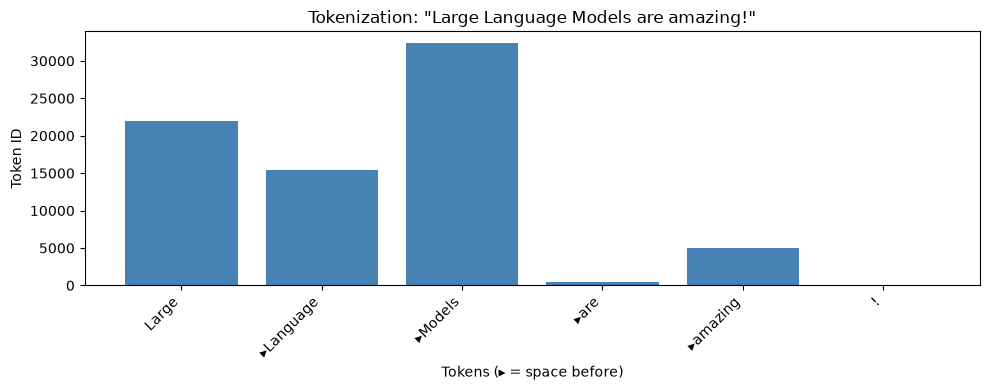

In [11]:
# Visualize tokenization
text = "Large Language Models are amazing!"
token_ids = tokenizer.encode(text)
tokens = tokenizer.convert_ids_to_tokens(token_ids)

# Clean display (replace Ġ with visible marker)
display_tokens = [t.replace('Ġ', '▸') for t in tokens]

plt.figure(figsize=(10, 4))
plt.bar(range(len(tokens)), token_ids, color='steelblue')
plt.xticks(range(len(tokens)), display_tokens, rotation=45, ha='right')
plt.xlabel('Tokens (▸ = space before)')
plt.ylabel('Token ID')
plt.title(f'Tokenization: "{text}"')
plt.tight_layout()
plt.show()

---

# Part 3: Embeddings - Giving Numbers Meaning

We can now convert text to numbers (tokenization). But token IDs are arbitrary - "cat" is 9246, "dog" is 9703. These numbers don't capture that cats and dogs are both animals!

**Embeddings** solve this: each token becomes a **vector** (list of numbers) where **similar words have similar vectors**.

```
TOKEN IDs (arbitrary):              EMBEDDINGS (meaningful):
─────────────────────               ────────────────────────

"cat" → 9246                        "cat" → [0.2, -0.5, 0.8, ...]  ┐
"dog" → 9703                        "dog" → [0.3, -0.4, 0.7, ...]  ├─ Similar vectors!
                                                                    │
"car" → 1097                        "car" → [-0.8, 0.2, 0.1, ...]  ┘ Different vector

The model LEARNS these vectors during training!
Similar words end up with similar embeddings.
```

In [12]:
# Get embedding layer from the model
# wte = Word Token Embeddings
embedding_layer = model.transformer.wte

print(f"Embedding shape: {embedding_layer.weight.shape}")
print(f"  → {tokenizer.vocab_size:,} tokens")
print(f"  → {embedding_layer.weight.shape[1]} dimensions per token")

Embedding shape: torch.Size([50257, 768])
  → 50,257 tokens
  → 768 dimensions per token


In [13]:
# Look up embeddings for some words
words = ["king", "queen", "man", "woman", "cat", "dog"]

embeddings_dict = {}
for word in words:
    # encode returns list of token IDs, [0] gets the first one
    token_id = tokenizer.encode(word)[0]

    # embedding_layer.weight is the embedding matrix [vocab_size, embed_dim]
    # embedding_layer.weight[token_id] gets the row for this token
    #
    # .detach() = disconnect from gradient computation graph
    #   (needed because model weights track gradients by default)
    # .numpy() = convert PyTorch tensor to NumPy array
    emb = embedding_layer.weight[token_id].detach().numpy()
    embeddings_dict[word] = emb

    # Show first 3 of 768 dimensions
    print(f"{word:8} → [{emb[0]:.3f}, {emb[1]:.3f}, {emb[2]:.3f}, ...]")

print(f"\nEach word = {len(emb)} numbers (768 dimensions)")

king     → [0.109, -0.395, 0.059, ...]
queen    → [0.015, -0.133, 0.117, ...]
man      → [-0.134, -0.138, 0.090, ...]
woman    → [-0.096, -0.077, 0.086, ...]
cat      → [-0.016, -0.093, 0.242, ...]
dog      → [0.063, 0.067, 0.096, ...]

Each word = 768 numbers (768 dimensions)


In [14]:
# Similar words have similar embeddings
# Cosine similarity: 1 = identical, 0 = unrelated, -1 = opposite

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

pairs = [("king", "queen"), ("cat", "dog"), ("king", "cat")]

print("WORD SIMILARITY:")
for w1, w2 in pairs:
    sim = cosine_sim(embeddings_dict[w1], embeddings_dict[w2])
    print(f"  {w1} ↔ {w2}: {sim:.3f}")

WORD SIMILARITY:
  king ↔ queen: 0.267
  cat ↔ dog: 0.382
  king ↔ cat: 0.214


---

# Part 4: Attention - How Transformers Understand Context

In Part 1, we learned that Transformers let every word "look at" every other word. Now let's understand **how** this works.

**Attention is THE mechanism that makes Transformers work.** Understanding attention is understanding Transformers.

> 📄 The attention mechanism comes from **"Attention Is All You Need"** (Vaswani et al., 2017).
> Paper: https://arxiv.org/abs/1706.03762

---

## The Problem Attention Solves

When understanding language, context matters. The same word can mean different things:

```
THE PRONOUN PROBLEM:

Sentence 1: "The animal didn't cross the street because it was too tired."
                                                      ↑
                                            What does "it" refer to?
                                            → "the animal" (animals get tired)

Sentence 2: "The animal didn't cross the street because it was too wide."
                                                      ↑
                                            What does "it" refer to?
                                            → "the street" (streets are wide)

To understand "it", the model must LOOK AT OTHER WORDS in the sentence!
This is what ATTENTION does.
```

## The Attention Mechanism: An Intuitive View

Think of attention as a **search engine** inside the model:

```
ATTENTION AS A LIBRARY SEARCH:

You (Query):     "I'm looking for information about cats"
                          ↓
                 ┌─────────────────────────────────────────────┐
                 │              LIBRARY (Keys)                 │
                 │                                             │
                 │  📖 "Dogs and their behavior"  → low match │
                 │  📖 "Cats: a complete guide"   → HIGH MATCH│
                 │  📖 "Cooking Italian food"     → no match  │
                 │  📖 "Feline health care"       → good match│
                 │                                             │
                 └─────────────────────────────────────────────┘
                          ↓
           Return weighted combination of book CONTENTS (Values)
           → Mostly from "Cats guide", some from "Feline health"

IN ATTENTION:
    Query (Q):  What am I looking for?
    Keys (K):   What does each word/position have to offer?
    Values (V): What is the actual content at each position?
```

## Self-Attention: Every Word Attends to Every Word

In **self-attention**, each word in a sentence looks at ALL other words:

```
SELF-ATTENTION VISUALIZATION:

Sentence: "The cat sat on the mat"

For each word, we ask: "Which other words should I pay attention to?"

                 The   cat   sat   on   the   mat
                  ↓     ↓     ↓    ↓     ↓     ↓
    The    →    [0.2   0.3   0.1  0.1   0.1   0.2]  ← weights (sum to 1)
    cat    →    [0.3   0.1   0.4  0.1   0.0   0.1]
    sat    →    [0.1   0.5   0.1  0.1   0.1   0.1]  ← "sat" attends most to "cat"
    on     →    [0.0   0.1   0.2  0.1   0.1   0.5]
    the    →    [0.0   0.0   0.1  0.1   0.1   0.7]
    mat    →    [0.0   0.3   0.2  0.3   0.1   0.1]

READING THIS:
    • Each row shows what that word attends to
    • Higher weight = "pay more attention to this word"
    • Row "sat" has 0.5 for "cat" = "sat" pays most attention to "cat"
    • This makes sense! "The cat sat" - subject/verb relationship
```

## The Attention Formula

This is the **Scaled Dot-Product Attention** from the original paper:

```
                        Q × Kᵀ
Attention(Q, K, V) = softmax(────────) × V
                         √d_k

STEP BY STEP:

1. Q × Kᵀ (dot product)
   → Compare each query to each key
   → High dot product = similar = should attend to this
   → Result: [seq_len × seq_len] matrix of raw scores

2. ÷ √d_k (scaling)
   → Divide by square root of dimension
   → WHY? Large dimensions → large dot products → softmax becomes too "sharp"
   → Scaling keeps gradients stable
   → This is why it's called "Scaled" Dot-Product Attention!

3. softmax (normalization)
   → Convert scores to probabilities (0-1, sum to 1)
   → Each row becomes a probability distribution
   → "How much should I attend to each position?"

4. × V (weighted sum)
   → Multiply attention weights by values
   → Result: New representation for each position
   → Weighted combination of all values, based on relevance
```

> 💡 This formula appears as **Equation (1)** in "Attention Is All You Need"

In [15]:
# Simple attention implementation

def simple_attention(Q, K, V):
    """
    Q = Query: what am I looking for? (shape: [seq_len, dim])
    K = Key: what do I have to offer? (shape: [seq_len, dim])
    V = Value: what's my content?     (shape: [seq_len, dim])
    """
    # Step 1: Compare Q to all K's using dot product (= similarity)
    # Q shape: [seq_len, dim], K.T shape: [dim, seq_len]
    # Result: [seq_len, seq_len] - similarity of each Q to each K
    # K.T = transpose (swap rows and columns)
    scores = torch.matmul(Q, K.T)

    # Step 2: Scale down scores
    # Why? Large dimensions → large dot products → softmax becomes too "sharp"
    # Dividing by sqrt(dim) keeps values in reasonable range
    d_k = K.shape[-1]  # -1 = last dimension = embedding dimension
    scores = scores / (d_k ** 0.5)  # same as / math.sqrt(d_k)

    # Step 3: Softmax along last dimension (dim=-1)
    # Each ROW becomes probabilities that sum to 1
    # Row i = how much token i attends to each other token
    weights = F.softmax(scores, dim=-1)

    # Step 4: Weighted sum of values
    # weights: [seq_len, seq_len], V: [seq_len, dim]
    # Result: [seq_len, dim] - new representation for each token
    output = torch.matmul(weights, V)

    return output, weights

# Demo with random vectors
torch.manual_seed(42)  # for reproducibility
x = torch.randn(4, 8)  # 4 tokens, 8 dimensions each

# Self-attention: Q=K=V=x (each token attends to all tokens including itself)
out, weights = simple_attention(x, x, x)

print("Attention weights shape:", weights.shape)  # [4, 4]
print("Each row shows how much that token attends to others:")
print(weights.numpy().round(2))

Attention weights shape: torch.Size([4, 4])
Each row shows how much that token attends to others:
[[0.98 0.01 0.   0.  ]
 [0.14 0.77 0.04 0.06]
 [0.01 0.03 0.81 0.15]
 [0.08 0.07 0.24 0.62]]


`GPT2SdpaAttention` is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


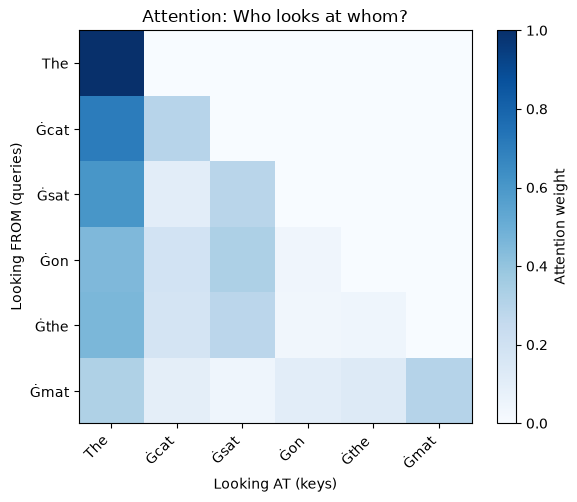

Reading the heatmap:
  Row = the token that's 'asking'
  Column = the token being 'looked at'
  Darker = more attention


In [16]:
# Visualize REAL attention from GPT-2

text = "The cat sat on the mat"
inputs = tokenizer(text, return_tensors="pt")

# output_attentions=True makes model return attention weights
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

# outputs.attentions is a tuple of attention from each layer
# outputs.attentions[0] = first layer's attention
# Shape: [batch, num_heads, seq_len, seq_len] = [1, 12, 6, 6]
#
# We get [0, 0] = first batch, first attention head
attn = outputs.attentions[0][0, 0].numpy()  # shape: [6, 6]
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(6, 5))
plt.imshow(attn, cmap='Blues')
plt.xticks(range(len(tokens)), tokens, rotation=45, ha='right')
plt.yticks(range(len(tokens)), tokens)
plt.xlabel('Looking AT (keys)')
plt.ylabel('Looking FROM (queries)')
plt.title('Attention: Who looks at whom?')
plt.colorbar(label='Attention weight')
plt.tight_layout()
plt.show()

print("Reading the heatmap:")
print("  Row = the token that's 'asking'")
print("  Column = the token being 'looked at'")
print("  Darker = more attention")

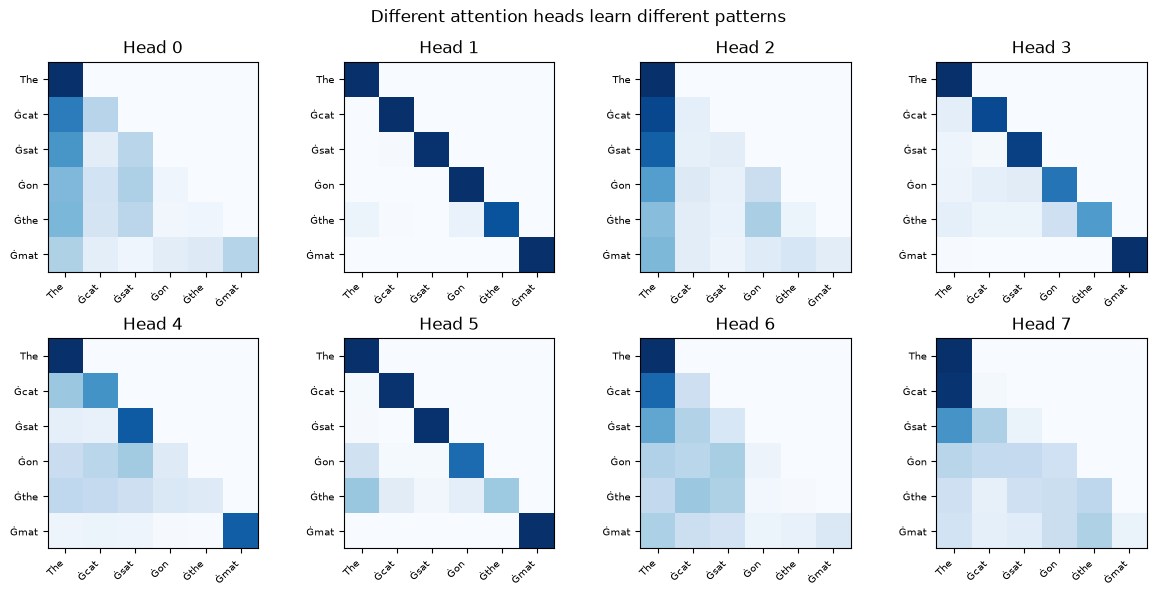

In [17]:
# GPT-2 has 12 attention heads - each learns different patterns

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for idx, ax in enumerate(axes.flat):
    attn = outputs.attentions[0][0, idx].numpy()
    ax.imshow(attn, cmap='Blues')
    ax.set_title(f'Head {idx}')
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=7)

plt.suptitle('Different attention heads learn different patterns')
plt.tight_layout()
plt.show()

---

## The Full Transformer Architecture

Now let's see how attention fits into the complete picture.

> 📄 This architecture is **Figure 1** from "Attention Is All You Need".
> GPT uses only the **decoder** (right side) of the original Transformer.

```
TRANSFORMER ARCHITECTURE (GPT-style, Decoder-only):

                            ┌─────────────────────────────┐
                            │     Output Probabilities     │
                            │   (one per vocab word)       │
                            └─────────────────────────────┘
                                          ↑
                            ┌─────────────────────────────┐
                            │    Linear + Softmax         │
                            │    (final Dense layer)      │
                            └─────────────────────────────┘
                                          ↑
            ╔═══════════════════════════════════════════════════════╗
            ║          TRANSFORMER BLOCK (repeated N times)         ║
            ║                                                       ║
            ║  ┌─────────────────────────────────────────────────┐ ║
            ║  │           Feed-Forward Network                   │ ║
            ║  │      (Dense → ReLU → Dense for each position)   │ ║
            ║  └─────────────────────────────────────────────────┘ ║
            ║                         ↑                            ║
            ║  ┌─────────────────────────────────────────────────┐ ║
            ║  │           Multi-Head Self-Attention              │ ║
            ║  │        (the magic we just learned!)              │ ║
            ║  └─────────────────────────────────────────────────┘ ║
            ╚═══════════════════════════════════════════════════════╝
                                          ↑
                            ┌─────────────────────────────┐
                            │    Positional Encoding      │
                            │  (adds position information)│
                            └─────────────────────────────┘
                                          ↑
                            ┌─────────────────────────────┐
                            │     Token Embeddings        │
                            │  (token IDs → vectors)      │
                            └─────────────────────────────┘
                                          ↑
                            ┌─────────────────────────────┐
                            │       Input Tokens          │
                            │   [15496, 11, 703, ...]     │
                            └─────────────────────────────┘


GPT-2 SPECIFICATIONS:
    • 12 Transformer blocks (layers)
    • 768 embedding dimensions
    • 12 attention heads per layer
    • 1024 token context window
    • ~117M parameters (small), ~1.5B parameters (XL)
```

## Multi-Head Attention: Why Multiple Heads?

GPT-2 has 12 attention heads per layer. Why?

> 📄 Multi-Head Attention is described in **Section 3.2.2** of "Attention Is All You Need":
> *"Multi-head attention allows the model to jointly attend to information from different representation subspaces."*

```
THE IDEA: Different heads learn different types of relationships!

HEAD 0:  Might learn SYNTACTIC patterns
         Subject-verb agreement
         "The cat [HEAD 0] sits" → cat and sits connected

HEAD 1:  Might learn SEMANTIC patterns  
         Related concepts
         "The cat [HEAD 1] chases the mouse" → cat and mouse connected

HEAD 2:  Might learn POSITIONAL patterns
         "Next word" relationships
         Each word attends to the previous word

HEAD 3:  Might learn RARE patterns
         Specific constructions
         Quotations, parentheses, etc.

... and so on ...

All heads' outputs are CONCATENATED and combined.
The model learns to use different heads for different purposes!
```

---

## Connection to CNNs (Day 3-4)

```
CNNs (Day 3):                           TRANSFORMERS (Today):
─────────────────                        ─────────────────────

Conv2D layers                            Self-Attention layers
  → Detect local spatial patterns          → Capture relationships between words
  → 3×3 filters see neighbors              → Each word can see ALL words

MaxPool2D                                (No equivalent)
  → Reduce spatial size                    → Keep all positions

Flatten + Dense                          Feed-Forward + Dense
  → Classification head                    → Prediction head

Hierarchical features:                   Hierarchical understanding:
  Layer 1: edges                           Layer 1: word meanings
  Layer 2: textures                        Layer 2: phrases
  Layer 3: parts                           Layer 3: sentences
  Layer N: objects                         Layer N: complex reasoning

SAME PRINCIPLE: Stack layers to build increasingly abstract representations!
```

---

# Part 5: Pretraining vs Fine-tuning

This is the **exact same concept** as Transfer Learning from Day 4! Just applied to text instead of images.

```
TRANSFER LEARNING (Day 4):              LLM TRAINING (Today):
════════════════════════                ═══════════════════════

Phase 1: PRETRAIN                       Phase 1: PRETRAIN
    VGG16 trained on ImageNet              GPT trained on internet text
    (1.2 million images)                   (billions of web pages)
    Learns: edges, textures, shapes        Learns: grammar, facts, reasoning
                  ↓                                     ↓
Phase 2: FINE-TUNE                      Phase 2: FINE-TUNE
    Adapt to YOUR task                     Adapt to YOUR task
    (flowers, medical images)              (chatbot, code, medical Q&A)
    Small dataset needed                   Small dataset needed
```

---

## Phase 1: Pretraining - Learning Language

```
WHAT HAPPENS DURING PRETRAINING:

Training Objective: Predict the next word!

Training Data: MASSIVE amounts of text
    • Books (entire libraries)
    • Wikipedia (all of it)
    • Web pages (billions)
    • Code repositories (GitHub)
    • Scientific papers
    • News articles
    • Conversations

Example training samples:
    Input:  "The mitochondria is the"      Target: "powerhouse"
    Input:  "import numpy as"               Target: "np"
    Input:  "To be or not to"               Target: "be"
    Input:  "The capital of Japan is"       Target: "Tokyo"
    Input:  "def fibonacci(n):"             Target: "if"
    ... BILLIONS more examples ...


WHAT THE MODEL LEARNS (emergently):
    ✓ Grammar and syntax ("He goes" not "He go")
    ✓ Facts and knowledge ("Paris is in France")
    ✓ Common sense ("Water is wet", "Fire is hot")
    ✓ Code patterns ("def" is followed by function name)
    ✓ Writing styles (formal vs casual)
    ✓ Multiple languages
    ✓ Reasoning patterns
    ✓ Math (to some extent)

All learned JUST by predicting next words!


COST OF PRETRAINING:
    ┌─────────────────────────────────────────────────────────┐
    │  Model        Estimated Cost      Training Time        │
    ├─────────────────────────────────────────────────────────┤
    │  GPT-2        ~$50,000            1 week               │
    │  GPT-3        ~$4.6 million       Several weeks        │
    │  GPT-4        ~$100+ million      Months               │
    │  GPT-5+       Hundreds of millions  ???                │
    └─────────────────────────────────────────────────────────┘

    You will NEVER pretrain your own LLM from scratch!
    Use pre-trained models instead. (That's the whole point!)
```

---

In [18]:
# PRETRAINING: Learn general language from massive data
print("PRETRAINING")
print("-" * 40)
print("Data:  Billions of documents")
print("Task:  Predict next word, over and over")
print("Cost:  $Millions, months of training")
print("Who:   Big companies (OpenAI, Google, etc.)")
print()

# Test what GPT-2 learned
print("What GPT-2 learned:")
predict_next("The Eiffel Tower is in", k=3)
predict_next("import pandas as", k=3)

PRETRAINING
----------------------------------------
Data:  Billions of documents
Task:  Predict next word, over and over
Cost:  $Millions, months of training
Who:   Big companies (OpenAI, Google, etc.)

What GPT-2 learned:
'The Eiffel Tower is in' →
    ' the' (24%)
    ' a' (9%)
    ' fact' (2%)

'import pandas as' →
    ' p' (25%)
    ' import' (5%)
    ' t' (4%)



In [19]:
# FINE-TUNING: Adapt pre-trained model to your task
print("PHASE 2: FINE-TUNING")
print("-" * 50)
print("""
Take a pre-trained model and adapt it for YOUR specific task.

EXAMPLES OF FINE-TUNING:

1. CHATBOT (ChatGPT, Claude):
   Training data: Conversations with human feedback
   "User: What's 2+2?  Assistant: 4"
   → Model learns to be helpful and conversational

2. CODE ASSISTANT (GitHub Copilot):
   Training data: Code + comments
   "# Function to reverse a string" → def reverse(...)
   → Model learns to write code from descriptions

3. MEDICAL Q&A:
   Training data: Medical literature + Q&A pairs
   → Model learns medical terminology and careful answers

4. SENTIMENT ANALYSIS:
   Training data: Reviews + labels
   "Great product!" → Positive
   "Terrible service" → Negative
   → Model learns to classify text sentiment

5. CUSTOMER SUPPORT:
   Training data: Your company's support tickets
   → Model learns your products, policies, tone
""")

PHASE 2: FINE-TUNING
--------------------------------------------------

Take a pre-trained model and adapt it for YOUR specific task.

EXAMPLES OF FINE-TUNING:

1. CHATBOT (ChatGPT, Claude):
   Training data: Conversations with human feedback
   "User: What's 2+2?  Assistant: 4"
   → Model learns to be helpful and conversational

2. CODE ASSISTANT (GitHub Copilot):
   Training data: Code + comments
   "# Function to reverse a string" → def reverse(...)
   → Model learns to write code from descriptions

3. MEDICAL Q&A:
   Training data: Medical literature + Q&A pairs
   → Model learns medical terminology and careful answers

4. SENTIMENT ANALYSIS:
   Training data: Reviews + labels
   "Great product!" → Positive
   "Terrible service" → Negative
   → Model learns to classify text sentiment

5. CUSTOMER SUPPORT:
   Training data: Your company's support tickets
   → Model learns your products, policies, tone



In [ ]:
# You can load different pre-trained models!
print("AVAILABLE MODELS (Hugging Face Hub):")
print("-" * 50)
models_info = [
    ("gpt2", "117M", "General text"),
    ("gpt2-medium", "345M", "Better quality"),
    ("distilgpt2", "82M", "Faster, smaller"),
    ("EleutherAI/gpt-neo-125m", "125M", "Open source alternative"),
    ("microsoft/DialoGPT-small", "117M", "Fine-tuned for dialogue"),
]

for name, params, desc in models_info:
    print(f"  {name:<30} {params:<8} {desc}")

print("\nAll work with the same code!")
print("Just change: AutoTokenizer.from_pretrained('model-name')")

---

# Part 6: Text Generation

Now that we understand the building blocks (tokenization → embeddings → attention → transformer), let's use the official API to generate text.

In Part 1, we saw how LLMs predict the **next word**. To generate longer text, we simply:
1. Predict next word
2. Append it to the input
3. Repeat

The `model.generate()` function does this for us automatically.

In [23]:
# Method 1: model.generate() - the standard way

prompt = "The future of AI is"

# Encode prompt to tensor (shape: [1, num_tokens])
input_ids = tokenizer.encode(prompt, return_tensors='pt')

# Generate new tokens
output_ids = model.generate(
    input_ids,
    max_new_tokens=30,    # Generate up to 30 new tokens
    do_sample=True,       # True = sample randomly, False = always pick most likely
    temperature=0.7,      # 0.0-2.0: lower = safer/boring, higher = creative/risky
    pad_token_id=tokenizer.eos_token_id  # What to use for padding (avoids warning)
)

# Decode back to text
# skip_special_tokens=True removes tokens like <|endoftext|>
output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print(f"Prompt: '{prompt}'")
print(f"Output: '{output_text}'")

Prompt: 'The future of AI is'
Output: 'The future of AI is still uncertain, and it's unclear what role the AI will play in human decision-making. As with the topic of machine learning, there are many'


In [24]:
# Temperature controls randomness
# Low (0.2) = conservative, predictable
# High (1.2) = creative, unexpected

prompt = "Once upon a time"
input_ids = tokenizer.encode(prompt, return_tensors='pt')

print(f"Prompt: '{prompt}'")
print("=" * 50)

for temp in [0.2, 0.7, 1.2]:
    output_ids = model.generate(
        input_ids,
        max_new_tokens=20,
        do_sample=True,
        temperature=temp,
        pad_token_id=tokenizer.eos_token_id
    )
    text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"\nTemp {temp}: {text}")

Prompt: 'Once upon a time'

Temp 0.2: Once upon a time, the world was a place of peace and harmony. But now, the world is a place of

Temp 0.7: Once upon a time, I was a big fan of the original series, but I couldn't wait to see what came

Temp 1.2: Once upon a time, I thought the only way to save a man or women was to get to heaven. God said


In [25]:
# Helper function for easy generation

def generate(prompt, max_tokens=30, temperature=0.7):
    """Generate text from a prompt."""
    input_ids = tokenizer.encode(prompt, return_tensors='pt')
    output_ids = model.generate(
        input_ids,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=temperature,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Try it!
print(generate("The best programming language is"))
print()
print(generate("def fibonacci(n):"))

The best programming language is Python, but it can be made more challenging by adding more functions. Here is an example to illustrate how the program can be compiled with:



def fibonacci(n): for n in range(n): for x in range(n): for i in range(n): for i in range(n): return fib


In [26]:
# Generate multiple different outputs
prompt = "Life is like a"

print(f"Prompt: '{prompt}'")
print("-" * 40)
for i in range(5):
    output = generate(prompt, max_tokens=15, temperature=0.8)
    continuation = output[len(prompt):]  # Just the new part
    print(f"{i+1}. ...{continuation}")

Prompt: 'Life is like a'
----------------------------------------
1. ... small garden of water. For me, this whole thing is a little bit
2. ... family, and my parents don't care what you think is going on in
3. ... world without walls or walls, where the best of the best move through the
4. ... dream. You feel like you're there, and you can't know what
5. ... nightmare. We all know that. We are all guilty of it. It


---

# Part 7: Limitations

GPT-2 is small and old. Let's see what it can't do.

In [27]:
# GPT-2 was trained on data up to ~2019
# It doesn't know about recent events

print("GPT-2 KNOWLEDGE CUTOFF (~2019):")
print("-" * 40)

prompts = [
    "ChatGPT was created by",      # 2022 - won't know
    "The COVID-19 pandemic",        # 2020 - might confuse
]

for p in prompts:
    result = generate(p, max_tokens=15)
    print(f"{result}")
    print("  ^ May be inaccurate\n")

GPT-2 KNOWLEDGE CUTOFF (~2019):
----------------------------------------
ChatGPT was created by a group at MIT with the aim of allowing developers to create and share code
  ^ May be inaccurate

The COVID-19 pandemic in the United States began in September 1918 and is now a major cause of
  ^ May be inaccurate



In [29]:
# Model size comparison
print("MODEL EVOLUTION:")
print("-" * 50)
print(f"{'Model':<25} {'Parameters':>12}")
print("-" * 50)
models = [
    ("Your MNIST CNN (Day 3)", "~100K"),
    ("VGG16 (Day 4)", "138M"),
    ("GPT-2 (this lecture)", "117M - 1.5B"),
    ("GPT-3 (2020)", "175B"),
    ("GPT-4 (2023)", "~1.7T"),
    ("GPT-5+ (2025)", "Even larger"),
]
for name, params in models:
    print(f"{name:<25} {params:>12}")

MODEL EVOLUTION:
--------------------------------------------------
Model                       Parameters
--------------------------------------------------
Your MNIST CNN (Day 3)           ~100K
VGG16 (Day 4)                     138M
GPT-2 (this lecture)       117M - 1.5B
GPT-3 (2020)                      175B
GPT-4 (2023)                     ~1.7T
GPT-5+ (2025)              Even larger


In [30]:
# ALL LLMs have limitations!
print("ALL LLMs CAN:")
print("  ✗ Hallucinate (make up false info)")
print("  ✗ Be biased (from training data)")
print("  ✗ Be inconsistent (different answers)")
print("  ✗ Miss recent events (knowledge cutoff)")
print()
print("→ Always verify important information!")

ALL LLMs CAN:
  ✗ Hallucinate (make up false info)
  ✗ Be biased (from training data)
  ✗ Be inconsistent (different answers)
  ✗ Miss recent events (knowledge cutoff)

→ Always verify important information!


---

# Summary: What We Learned Today

Let's trace the story we just told:

**The Problem:** How do we build neural networks for text?

**The Solution:** LLMs - neural networks that predict the next word, trained on massive text data.

**The Architecture:** Transformers - use self-attention to let every word look at every other word.

**The Strategy:** Pretrain on huge data, then fine-tune for specific tasks.

---

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    LLM DAY 1 - KEY TAKEAWAYS                           │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  1. WHAT ARE LLMs?                                                     │
│     • Neural networks trained to predict the next word                 │
│     • "Large" = billions of parameters + massive training data         │
│     • Generate text by predicting one word at a time (autoregressive)  │
│     • Same softmax output as classification, but 50K+ classes!         │
│                                                                         │
│  2. TOKENIZATION                                                       │
│     • Converting text ↔ numbers (neural nets only understand numbers) │
│     • Subword tokenization: balance between words and characters       │
│     • GPT-2 uses ~50,000 token vocabulary                              │
│     • 'Ġ' prefix = space before token                                   │
│                                                                         │
│  3. EMBEDDINGS                                                         │
│     • Token IDs → dense vectors (768 dimensions in GPT-2)              │
│     • Similar words have similar embeddings                            │
│     • Model learns these during training                               │
│                                                                         │
│  4. ATTENTION (The Key Innovation!)                                    │
│     • Each word "attends to" all other words                           │
│     • Query-Key-Value: like searching a library                        │
│     • Attention(Q,K,V) = softmax(QK^T / √d) × V                        │
│     • Multi-head: different heads learn different patterns             │
│                                                                         │
│  5. TRANSFORMER ARCHITECTURE                                           │
│     • Stacked blocks of: Self-Attention → Feed-Forward                 │
│     • Positional encoding adds position information                    │
│     • Parallel processing (unlike RNNs) = fast training!               │
│                                                                         │
│  6. PRETRAINING vs FINE-TUNING                                        │
│     • Pretraining: Learn general language ($millions, months)          │
│     • Fine-tuning: Adapt to specific task ($hundreds, hours)           │
│     • Same concept as Transfer Learning (Day 4)!                       │
│     • You use pre-trained models, not train from scratch               │
│                                                                         │
│  7. TEXT GENERATION                                                    │
│     • Autoregressive: predict next, append, repeat                     │
│     • Temperature: controls randomness (low=safe, high=creative)       │
│     • Use Hugging Face transformers library                            │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

---

## 📄 The Foundational Paper

Everything we learned today comes from one groundbreaking paper:

> **"Attention Is All You Need"**
> Vaswani, Shazeer, Parmar, Uszkoreit, Jones, Gomez, Kaiser, Polosukhin (2017)
> https://arxiv.org/abs/1706.03762

This paper introduced:
- The **Transformer** architecture
- **Scaled Dot-Product Attention** (the formula we implemented)
- **Multi-Head Attention** (multiple attention patterns)
- **Positional Encoding** (adding position information)

If you want to go deeper, read this paper. It's the foundation of GPT, BERT, Claude, and every modern LLM.

---

## Key Functions Reference

| Function | What it does |
|----------|-------------|
| `AutoTokenizer.from_pretrained("gpt2")` | Load tokenizer for model |
| `AutoModelForCausalLM.from_pretrained("gpt2")` | Load pre-trained LLM |
| `tokenizer.encode(text)` | Text → token IDs |
| `tokenizer.decode(ids)` | Token IDs → text |
| `tokenizer.convert_ids_to_tokens(ids)` | IDs → token strings |
| `model(**inputs)` | Get model predictions |
| `model.generate(...)` | Generate new tokens |
| `torch.no_grad()` | Disable gradients (inference mode) |
| `F.softmax(logits, dim=-1)` | Scores → probabilities |

---

## Key Parameters Reference

| Parameter | Meaning |
|-----------|---------|
| `dim=-1` | Last dimension (works for any tensor shape) |
| `return_tensors="pt"` | Return PyTorch tensor |
| `max_new_tokens=30` | How many tokens to generate |
| `temperature=0.7` | Randomness (0=deterministic, 1+=creative) |
| `do_sample=True` | Sample from distribution (vs greedy) |
| `.detach()` | Remove from gradient computation |

---

## Connecting to Your Exercises

```
┌─────────────────────────────────────────────────────────────────────┐
│  EXERCISE 1: What are LLMs?                                        │
│  → You learned this in Part 1                                      │
│  → Load GPT-2 model and tokenizer (we did this!)                  │
│                                                                     │
│  EXERCISE 2: Tokenization                                          │
│  → You learned this in Part 2                                      │
│  → Tokenize text, visualize with bar chart                        │
│                                                                     │
│  EXERCISE 3: Token IDs and Special Prefixes                        │
│  → You learned about 'Ġ' prefix in Part 2                          │
│  → Print IDs, explain the prefix                                   │
│                                                                     │
│  EXERCISE 4: Pretraining vs Fine-Tuning                            │
│  → You learned this in Part 5                                      │
│  → Explain in your own words                                       │
│                                                                     │
│  EXERCISE 5: Generate Text                                         │
│  → You learned this in Part 6                                      │
│  → Use model.generate() to create text                             │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

# Great work! You now understand the fundamentals of Large Language Models!

**Remember:**
- LLMs are just neural networks that predict the next word
- Tokenization converts text to numbers the model can process
- Attention lets words communicate with each other
- Pre-trained models are the foundation - fine-tuning adapts them
- The Transformer architecture made all of this possible

**Now go complete those exercises!**

---

---

# Bonus: Preparing for Advanced Exercises

The exercises include building a **spam classifier** using attention. Here's what you need to know beyond today's lecture.

## Different Model Heads: Generation vs Classification

We used `AutoModelForCausalLM` today - the "Causal Language Model" head for **text generation**.

For **classification tasks** (spam/not spam), we swap the head:

```
AutoModelForCausalLM (Today)              GPT2ForSequenceClassification (Exercises)
────────────────────────────              ─────────────────────────────────────────

Task: Predict next word                   Task: Classify whole text

"The cat sat" → "on" (next word)          "Free iPhone! Click now!" → spam (0.92)

Output layer: 768 → 50,257                Output layer: 768 → 2
              (vocab size)                             (num classes)

Same GPT-2 backbone, different final layer!
(Just like Transfer Learning in Day 4 - same VGG16, different head)
```

In [ ]:
# Classification model - just a different import!
from transformers import GPT2ForSequenceClassification

# Load GPT-2 with a classification head instead of generation head
classifier = GPT2ForSequenceClassification.from_pretrained(
    "gpt2",
    num_labels=2,  # 2 classes: spam vs ham (not spam)
    pad_token_id=tokenizer.eos_token_id  # GPT-2 needs this for padding
)

print(f"Classification model loaded!")
print(f"Output: {classifier.config.num_labels} classes (instead of 50,257 vocab words)")

## The `evaluate` Library

For measuring model performance, Hugging Face provides the `evaluate` library (same metrics you know from scikit-learn, but integrated with transformers):

In [ ]:
# !pip install evaluate --quiet  # Run once if needed

import evaluate

# Load metrics (same ones you know!)
accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

# Example: evaluate some predictions
predictions = [1, 0, 1, 1, 0]  # Model predicted: spam, ham, spam, spam, ham
references  = [1, 0, 0, 1, 0]  # True labels:     spam, ham, ham,  spam, ham

print("Metrics:")
print(f"  Accuracy:  {accuracy.compute(predictions=predictions, references=references)['accuracy']:.2f}")
print(f"  Precision: {precision.compute(predictions=predictions, references=references)['precision']:.2f}")
print(f"  Recall:    {recall.compute(predictions=predictions, references=references)['recall']:.2f}")
print(f"  F1:        {f1.compute(predictions=predictions, references=references)['f1']:.2f}")

## What You'll Build in the Advanced Exercises

```
┌─────────────────────────────────────────────────────────────────────┐
│  SMS SPAM CLASSIFIER - Two Approaches                              │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  APPROACH 1: Pre-trained GPT-2                                     │
│  ─────────────────────────────                                      │
│  GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=2)│
│  → Uses all the knowledge GPT-2 learned from internet              │
│  → Just need to show it some spam examples                         │
│                                                                     │
│  APPROACH 2: Custom Attention Model (from scratch)                 │
│  ──────────────────────────────────────────────────                 │
│  Build your own: Embedding → Attention → Linear                    │
│  → Implement the attention formula yourself                        │
│  → Much smaller, trains from zero                                  │
│                                                                     │
│  COMPARE: Which works better? Why?                                 │
│  → Pre-trained models have a huge advantage (transfer learning!)   │
│  → But understanding attention from scratch = deeper learning      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

You already know everything needed - now it's time to apply it!

---